![Finance Toolkit](https://github.com/JerBouma/FinanceToolkit/assets/46355364/198d47bd-e1b3-492d-acc4-5d9f02d1d009)

**The FinanceToolkit** is an open-source toolkit in which all relevant financial ratios (100+), indicators and performance measurements are written down in the most simplistic way allowing for complete transparency of the calculation method. This allows you to not have to rely on metrics from other providers and, given a financial statement, allow for efficient manual calculations. This leads to one uniform method of calculation being applied that is available and understood by everyone.

# Installation
To install the FinanceToolkit it simply requires the following:

```
pip install financetoolkit -U
```

From within Python use:

```python
from financetoolkit import Toolkit
```
 
To be able to get started, you need to obtain an API Key from FinancialModelingPrep. This is used to gain access to 30+ years of financial statement both annually and quarterly. Note that the Free plan is limited to 250 requests each day, 5 years of data and only features companies listed on US exchanges.

___ 

<b><div align="center">Obtain an API Key from FinancialModelingPrep <a href="https://www.jeroenbouma.com/fmp" target="_blank">here</a>.</div></b>
___

Through the link you are able to subscribe for the free plan and also premium plans at a **15% discount**. This is an affiliate link and thus supports the project at the same time. I have chosen FinancialModelingPrep as a source as I find it to be the most transparent, reliable and at an affordable price. When you notice that data is inaccurate or have any other issue related to the data, note that I simply provide the means to access this data and I am not responsible for the accuracy of the data itself. For this, use <a href="https://site.financialmodelingprep.com/contact" target="_blank">their contact form</a> or provide the data yourself. 

The current Notebook is revolved around the Techniclas class. If you are interested in the other modules, you can find the related Notebooks below. **Please view the documentation <a href="https://www.jeroenbouma.com/projects/financetoolkit/docs/technicals" target="_blank">here</a> to find all the available indicators.**

<style>
.button {
  color: #fff !important;
  background-color: #58abc4;
  display: inline-block;
  margin-bottom: 0.25em;
  padding: 0.5em 1em;
  font-family: -apple-system,BlinkMacSystemFont,"Roboto","Segoe UI","Helvetica Neue","Lucida Grande",Arial,sans-serif;
  font-size: .75em;
  font-weight: bold;
  text-align: center;
  text-decoration: none;
  border-width: 0;
  border-radius: 4px;
  cursor: pointer;
}

.button-current {
  background-color: #d67f05;
}

a:hover {
  color: #fff !important;
  font-weight: normal !important;
}
</style>

<div style="display: flex; justify-content: space-between;" class="show-on-desktop">
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//getting-started" target="_blank" class="button" style="flex: 1;margin-right:5px"">Toolkit</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//discovery-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Discovery</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//ratios-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Ratios</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//models-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Models</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//options-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Options</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//technicals-module" target="_blank" class="button button-current" style="flex: 1;margin-right:5px">Technicals</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//risk-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Risk</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//performance-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Performance</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//economics-module"  target="_blank" class="button" style="flex: 1;margin-right:5px">Economics</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//fixed-income-module" target="_blank" class="button" style="flex: 1;margin-right:5px">Fixed income</a>
    <a href="https://www.jeroenbouma.com/projects/financetoolkit//portfolio-module" target="_blank" class="button" style="flex: 1; ">Portfolio</a>
</div>

In [5]:
import json
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import patheffects
from pathlib import Path

# Set FMP cache test mode to false
os.environ['FMP_CACHE_TEST_MODE'] = 'false'
os.environ['FMP_CACHE_AUTO_CREATE_DB'] = 'false'

# Add FinanceToolkit source to path
finance_toolkit_path = Path.home() / "masterswork" / "git" / "OpenBB" / "FinanceToolkit"
if str(finance_toolkit_path) not in sys.path:
    sys.path.insert(0, str(finance_toolkit_path))

from financetoolkit import Toolkit

# Load FMP API key from OpenBB user settings
user_settings_path = Path.home() / ".openbb_platform" / "user_settings.json"
with open(user_settings_path) as f:
    settings = json.load(f)
    API_KEY = settings["credentials"]["fmp_api_key"]

**Initializing only is required once.** This is the case for any function so once you have obtained a balance sheet statement, it will be stored accordingly which means that requests to FinancialModelingPrep, the source used in these examples, are kept to a minimum. Note that in this example annual data is used but by adding `quarterly=True` to the Toolkit initialization, quarterly data can also be collected. Note that this requires a Premium subscription from FMP.

In [6]:
# Initialize the Toolkit with company tickers
companies = Toolkit(
    ["MSFT", "ASML", "MU", "AMZN"],
    api_key=API_KEY,
    start_date="2025-01-01",
    end_date="2025-11-26", 
    enforce_source="FinancialModelingPrep"
)


After initialization of `Toolkit`, you can get access to the Technicals module which includes a variety of well-known technical indicators. This can be done by calling the `technicals` property. Some of the technical indicators you can find here are for example a collection of all technical indicators.

In [7]:
companies.technicals.collect_all_indicators()

2025-11-29 15:44:39 - financetoolkit - INFO - [Tier 1/3] Attempting to retrieve ^TNX data using OpenBB Platform cached provider


Cache analysis failed for ^TNX: Unauthorized FMP request -> 402 -> Premium Query Parameter: 'Special Endpoint : This value set for 'symbol' is not available under your current subscription please visit our subscription page to upgrade your plan at https://financialmodelingprep.com/


2025-11-29 15:44:39 - financetoolkit - WARNING - [Tier 1/3] OpenBB Platform cached provider failed for ^TNX: 
[Error] -> Unauthorized FMP request -> 402 -> Premium Query Parameter: 'Special Endpoint : This value set for 'symbol' is not available under your current subscription please visit our subscription page to upgrade your plan at https://financialmodelingprep.com/. Falling back to direct FMP API.
2025-11-29 15:44:39 - financetoolkit - INFO - [Tier 2/3] Retrieving ^TNX data using direct FMP API
2025-11-29 15:44:40 - financetoolkit - WARNING - [Tier 2/3] Direct FMP API returned empty data for ^TNX
2025-11-29 15:44:40 - financetoolkit - INFO - [Tier 3/3] Attempting CBOE free provider as final fallback for ^TNX
2025-11-29 15:44:40 - financetoolkit - WARNING - CBOE provider does not support dividends for ^TNX. Dividend data will be set to 0.
2025-11-29 15:44:40 - financetoolkit - INFO - Attempting to retrieve ^TNX data using CBOE provider (fallback)
2025-11-29 15:44:40 - financetoolkit

Obtaining historical data:   0%|          | 0/5 [00:00<?, ?it/s]

2025-11-29 15:44:40 - financetoolkit - INFO - [Tier 1/3] Attempting to retrieve MSFT data using OpenBB Platform cached provider


...

Obtaining historical data: 100%|██████████| 5/5 [00:00<00:00,  8.93it/s]
Still have 1 gaps after caching for ASML
Still have 1 gaps after caching for MU
Still have 1 gaps after caching for AMZN
Still have 1 gaps after caching for MSFT


2025-11-29 15:44:56 - financetoolkit - INFO - [OK] Successfully retrieved AMZN data from OpenBB Platform cache


Still have 1 gaps after caching for SPY


2025-11-29 15:44:59 - financetoolkit - INFO - [OK] Successfully retrieved ASML data from OpenBB Platform cache
2025-11-29 15:44:59 - financetoolkit - INFO - [OK] Successfully retrieved MU data from OpenBB Platform cache
2025-11-29 15:44:59 - financetoolkit - INFO - [OK] Successfully retrieved MSFT data from OpenBB Platform cache
2025-11-29 15:44:59 - financetoolkit - INFO - [OK] Successfully retrieved SPY data from OpenBB Platform cache


McClellan Oscillator                                     \
                           MSFT     ASML      MU    AMZN Benchmark   
Date                                                                 
2025-01-02                  0.0      0.0     0.0     0.0       0.0   
2025-01-03              21.1675   35.718  4.4935 11.2095   29.5975   
2025-01-06              39.3849  68.7858  8.7825 20.9086   54.9259   
2025-01-07              54.4898  96.1683 12.5381 28.8217   75.9705   
2025-01-08              67.2416 118.4196 15.5615 35.4444   93.6268   
...                         ...      ...     ...     ...       ...   
2025-11-20              -4.6151  23.3584 15.7781  1.7414    1.7548   
2025-11-21              -6.0224  19.4689  14.042  1.0633    1.1078   
2025-11-24              -7.1015  17.1085 13.3153  0.7578     1.034   
2025-11-25              -7.8391  15.7748 12.6575  0.6622    1.2803   
2025-11-26              -8.0051  16.4431 12.3182  0.5517    1.7174   

           Advancers - Decliners                                  ...  \
                            MSFT    ASML     MU   AMZN Benchmark  ...   
Date                                                              ...   
2025-01-02                   0.0     0.0    0.0    0.0       0.0  ...   
2025-01-03                423.35  714.36  89.87 224.19    591.95  ...   
2025-01-06                427.85  768.51  99.26 227.61    595.36  ...   
2025-01-07                422.37  757.58 101.91 222.11    588.63  ...   
2025-01-08                424.56  743.98  99.41 222.13    589.49  ...   
...                          ...     ...    ...    ...       ...  ...   
2025-11-20                478.43  981.04 201.37 217.14    652.53  ...   
2025-11-21                472.12  966.57 207.37 220.69    659.03  ...   
2025-11-24                 474.0  987.82 223.93 226.28    668.73  ...   
2025-11-25                476.99 1003.22 224.53 229.67    675.02  ...   
2025-11-26                 485.5 1040.97 230.26 229.16    679.68  ...   

           Keltner Channel Middle                                        \
                             AMZN      ASML Benchmark     MSFT       MU   
Date                                                                      
2025-01-02                 220.22    700.42    584.64   418.58    87.33   
2025-01-03               220.7493  702.2787  585.6147  419.216  87.6687   
2025-01-06               221.6641  711.1095   586.914 420.3672  89.2142   
2025-01-07               221.7235  717.3056  587.1428 420.6342   90.907   
2025-01-08               221.7777  720.8622  587.4558 421.1577  92.0407   
...                           ...       ...       ...      ...      ...   
2025-11-20               232.2173 1020.7688  669.1061 501.9075 228.6937   
2025-11-21               230.6804 1013.5423  667.7626 497.9359 225.8506   
2025-11-24               230.0937 1010.1126  667.8916 494.7444 225.5945   
2025-11-25               230.0372 1009.1936   668.842 492.3772 225.4525   
2025-11-26               229.9202 1013.4305  670.2871 491.4602 226.0935   

           Keltner Channel Lower                                       
                            AMZN     ASML Benchmark     MSFT       MU  
Date                                                                   
2025-01-02                 206.3   669.18    563.38   396.14    81.51  
2025-01-03              208.6493 669.5087  567.0247  402.546  81.8887  
2025-01-06              210.4974 644.7762   569.354 401.9405  77.5942  
2025-01-07              209.8885 655.1056  568.4878 401.8892   78.452  
2025-01-08              210.9817 662.8702  570.3798 403.9897  80.0047  
...                          ...      ...       ...      ...      ...  
2025-11-20              217.3531 960.1631  649.2546 479.0733 192.6209  
2025-11-21              216.8661 949.9709  646.7911 475.0616 188.9834  
2025-11-24              216.5237 947.8869  646.5959 471.9144 188.5216  
2025-11-25              216.1986 945.1622  646.8263 468.6886 190.0454  
2025-11-26          

Individual indicators are also available such as the Bollinger Bands and plot accordingly.

# Bollinger Bands - Comprehensive Guide

## What Are Bollinger Bands?

Bollinger Bands are a technical analysis tool invented by **John Bollinger** in the 1980s. They consist of three lines plotted on a price chart that help traders identify volatility, potential overbought/oversold conditions, and price breakouts.

## The Three Components

1. **Middle Band (SMA)**: Simple Moving Average (typically 20-day)
2. **Upper Band**: Middle Band + (Standard Deviation × 2)
3. **Lower Band**: Middle Band - (Standard Deviation × 2)

## Mathematical Formula

```
Middle Band = SMA(Close, n)
Upper Band = SMA(Close, n) + (k × σ)
Lower Band = SMA(Close, n) - (k × σ)

Where:
- n = number of periods (typically 20)
- k = number of standard deviations (typically 2)
- σ = standard deviation of price over n periods
```

## How Bollinger Bands Work

### 1. **Volatility Indicator**
- **Narrow bands** → Low volatility → Potential breakout coming
- **Wide bands** → High volatility → Market is active

### 2. **Overbought/Oversold Signals**
- Price touches **upper band** → Potentially overbought
- Price touches **lower band** → Potentially oversold

### 3. **Trend Strength**
- Price consistently hugging upper band → Strong uptrend
- Price consistently hugging lower band → Strong downtrend

## Trading Strategies

### Strategy 1: Bollinger Bounce
**When to use**: In ranging markets

- **Buy Signal**: Price touches or crosses below the lower band
- **Sell Signal**: Price touches or crosses above the upper band
- **Logic**: Prices tend to return to the middle band (mean reversion)

### Strategy 2: Bollinger Squeeze
**When to use**: Before major price movements

- **Setup**: Bands contract significantly (low volatility)
- **Signal**: Wait for price breakout above/below the bands
- **Action**: Trade in the direction of the breakout
- **Logic**: Low volatility periods are often followed by high volatility

### Strategy 3: Riding the Bands
**When to use**: In strong trending markets

- **Uptrend**: Price walks along the upper band
- **Downtrend**: Price walks along the lower band
- **Action**: Don't fade the trend just because price touches the band
- **Logic**: Strong trends can run along the bands for extended periods

## Practical Example

Let's say Microsoft (MSFT) stock is trading with these values:

| Date | Close Price | Middle Band (20-day SMA) | Upper Band | Lower Band |
|------|-------------|--------------------------|------------|------------|
| Day 1 | $380 | $375 | $390 | $360 |
| Day 2 | $392 | $376 | $391 | $361 |
| Day 3 | $385 | $377 | $392 | $362 |

**Analysis:**
- **Day 1**: Price at $380, between middle and upper band → Neutral to bullish
- **Day 2**: Price at $392, **above upper band** → Potentially overbought, consider taking profits
- **Day 3**: Price at $385, returned toward middle → Normal price action, confirming Bollinger bounce

## Important Considerations

### ⚠️ Limitations

1. **Not a standalone indicator**: Should be combined with other indicators (RSI, MACD, volume)
2. **False signals**: Can give false buy/sell signals in strong trends
3. **Lagging indicator**: Based on historical data, not predictive
4. **Parameter sensitivity**: Different settings work for different assets/timeframes

### ✅ Best Practices

1. **Confirm with volume**: High volume breakouts are more reliable
2. **Use multiple timeframes**: Check daily, weekly for confirmation
3. **Adjust parameters**: Test different periods (10, 20, 50) and standard deviations (1.5, 2, 2.5)
4. **Consider market context**: Trending vs ranging markets require different interpretations

## Statistical Interpretation

Based on the **68-95-99.7 rule** (normal distribution):
- ~68% of price action occurs within **1 standard deviation**
- ~95% of price action occurs within **2 standard deviations** (default)
- ~99.7% of price action occurs within **3 standard deviations**

This means that with 2 standard deviations:
- Only ~5% of price movements should occur outside the bands
- When price exceeds bands, it's a **statistically significant event**

## Code Example (Python)

```python
from financetoolkit import Toolkit

companies = Toolkit(
    ["MSFT", "AAPL"], 
    api_key="your_api_key",
    start_date="2024-01-01",
    end_date="2024-12-31"
)

# Get Bollinger Bands with default parameters (20-day, 2 std dev)
bollinger_bands = companies.technicals.get_bollinger_bands()

# Custom parameters
bollinger_bands_custom = companies.technicals.get_bollinger_bands(
    window=14,        # 14-day moving average
    num_std_dev=2.5   # 2.5 standard deviations
)
```

## Visual Example

```
Price Chart with Bollinger Bands:

$400 ┤     Upper Band ─────────────────────
     │           ╱╲        ╱╲
$390 ┤      ╱──╱  ╲──────╱  ╲────
     │     ╱                      ╲
$380 ┤────● Middle Band (SMA) ─────●───
     │   ╱                            ╲
$370 ┤  ╱                              ╲
     │ ╱                                ╲
$360 ┤╱  Lower Band ──────────────────── ╲
     └──────────────────────────────────────
        Time →

● = Current Price
```

## Key Insights

- **Band width** indicates volatility
- **Price position** relative to bands shows strength
- **Band direction** shows trend
- **Band touches** can signal reversals (in range) or continuations (in trend)

## Sources & Further Reading

### Original Sources
- 📚 **Bollinger, John**. *Bollinger on Bollinger Bands*. McGraw-Hill, 2001.
  - [Amazon Link](https://www.amazon.com/Bollinger-Bands-John/dp/0071373683)

### Official Resources
- 🌐 **Official Bollinger Bands Website**: [BollingerBands.com](https://www.bollingerbands.com/)
- 📖 **Bollinger Band Rules**: [22 Rules](https://www.bollingerbands.com/bollinger-band-rules)

### Educational Resources
- 📊 **Investopedia - Bollinger Bands**: [Complete Guide](https://www.investopedia.com/terms/b/bollingerbands.asp)
- 📈 **TradingView - Bollinger Bands**: [Technical Analysis](https://www.tradingview.com/support/solutions/43000501971-bollinger-bands-bb/)
- 🎓 **Babypips - Bollinger Bands**: [Trading Tutorial](https://www.babypips.com/learn/forex/bollinger-bands)

### Academic & Research
- 📄 **Lento, C., Gradojevic, N.** "The profitability of technical trading rules: a combined signal approach" (2007)
  - [SSRN Link](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1428671)
- 📄 **Kaufman, P.J.** *Trading Systems and Methods*. Wiley, 2013.

### Video Tutorials
- 🎥 **John Bollinger's Official Channel**: [YouTube](https://www.youtube.com/user/BollingerBands)
- 🎥 **Investopedia Academy**: [Bollinger Bands Tutorial](https://academy.investopedia.com/)

### Python Implementation
- 💻 **TA-Lib Documentation**: [Technical Analysis Library](https://ta-lib.org/)
- 💻 **Pandas TA**: [GitHub Repository](https://github.com/twopirllc/pandas-ta)
- 💻 **FinanceToolkit**: [Documentation](https://www.jeroenbouma.com/projects/financetoolkit/docs/technicals)

### Interactive Tools
- 🔧 **TradingView**: [Interactive Charts](https://www.tradingview.com/)
- 🔧 **StockCharts**: [ChartSchool](https://school.stockcharts.com/doku.php?id=technical_indicators:bollinger_bands)

---

**Remember**: Bollinger Bands are a tool, not a crystal ball. Always combine with:
- Volume analysis
- Other technical indicators (RSI, MACD)
- Fundamental analysis
- Risk management strategies
- Market context awareness

Close                                 Lower Band           \
             AMZN    ASML Benchmark   MSFT     MU       AMZN     ASML   
Date                                                                    
2025-01-02 220.22  700.42    584.64 418.58  87.33        NaN      NaN   
2025-01-03 224.19  714.36    591.95 423.35  89.87        NaN      NaN   
2025-01-06 227.61  768.51    595.36 427.85  99.26        NaN      NaN   
2025-01-07 222.11  757.58    588.63 422.37 101.91        NaN      NaN   
2025-01-08 222.13  743.98    589.49 424.56  99.41        NaN      NaN   
...           ...     ...       ...    ...    ...        ...      ...   
2025-11-20 217.14  981.04    652.53 478.43 201.37   215.8221 984.3122   
2025-11-21 220.69  966.57    659.03 472.12 207.37   213.1113 973.4225   
2025-11-24 226.28  987.82    668.73  474.0 223.93   211.9781 968.1847   
2025-11-25 229.67 1003.22    675.02 476.99 224.53   212.0234 967.9144   
2025-11-26 229.16 1040.97    679.68  485.5 230.26   211.5855 966.9779   

                                       Middle Band                      \
           Benchmark     MSFT       MU        AMZN      ASML Benchmark   
Date                                                                     
2025-01-02       NaN      NaN      NaN         NaN       NaN       NaN   
2025-01-03       NaN      NaN      NaN         NaN       NaN       NaN   
2025-01-06       NaN      NaN      NaN         NaN       NaN       NaN   
2025-01-07       NaN      NaN      NaN         NaN       NaN       NaN   
2025-01-08       NaN      NaN      NaN         NaN       NaN       NaN   
...              ...      ...      ...         ...       ...       ...   
2025-11-20  653.2403 481.0239 208.6052    239.2993 1025.4771  672.1529   
2025-11-21  651.4645 473.9744 202.8257      236.92 1018.3164  670.4164   
2025-11-24  651.1908 469.2478 203.9869    235.2743 1015.2936  669.9514   
2025-11-25  651.2803 465.9281 202.8164    233.8079 1012.3986  669.7686   
2025-11-26  651.2019 464.7524 202.4283    232.8164 1013.2393  670.4379   

                             Upper Band                                        
               MSFT       MU       AMZN      ASML Benchmark     MSFT       MU  
Date                                                                           
2025-01-02      NaN      NaN        NaN       NaN       NaN      NaN      NaN  
2025-01-03      NaN      NaN        NaN       NaN       NaN      NaN      NaN  
2025-01-06      NaN      NaN        NaN       NaN       NaN      NaN      NaN  
2025-01-07      NaN      NaN        NaN       NaN       NaN      NaN      NaN  
2025-01-08      NaN      NaN        NaN       NaN       NaN      NaN      NaN  
...             ...      ...        ...       ...       ...      ...      ...  
2025-11-20 502.7543 234.8079   262.7765 1066.6421  691.0654 524.4846 261.0105  
2025-11-21 499.5464 232.8557   260.7287 1063.2103  689.3684 525.1185 262.8857  
2025-11-24 496.6657 233.2771   258.5704 1062.4025   688.712 524.0836 262.5674  
2025-11-25 494.5107 232.3507   255.5924 1056.8827  688.2568 523.0934  261.885  
2025-11-26 493.6821 231.7743   254.0473 1059.5007  689.6738 522.6119 261.1203  

[227 rows x 20 columns]

<Axes: title={'center': "Microsoft's Bollinger Bands"}, xlabel='Date'>

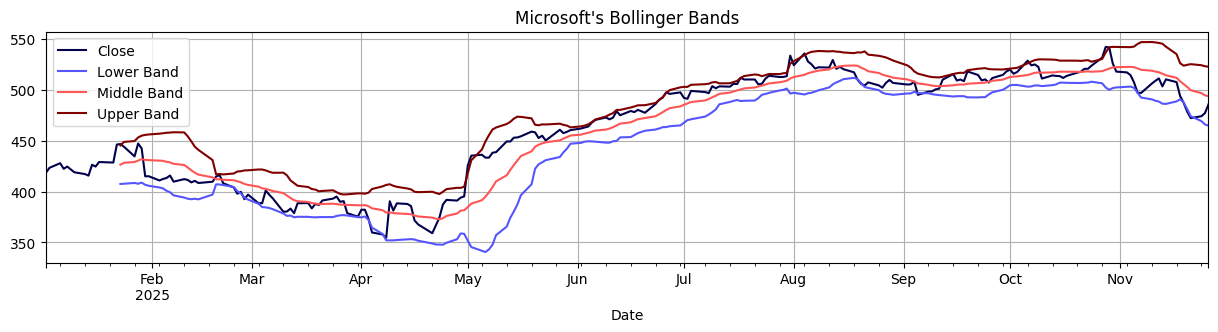

In [8]:
bollinger_bands = companies.technicals.get_bollinger_bands()

display(bollinger_bands)

bollinger_bands.xs("MSFT", level=1, axis=1).plot(
    figsize=(15, 3),
    title="Microsoft's Bollinger Bands",
    grid=True,
    legend=True,
    colormap="seismic",
)

Each functionality also has the ability to change parameters. As an example, the window for the Average Directional Index can be changed and the growth and lag can also be defined.

In [5]:
companies.technicals.get_average_directional_index(
    window=20, growth=True, lag=[1, 3, 5, 10]
)

MSFT                            ASML                          \
             Lag 1   Lag 3   Lag 5  Lag 10   Lag 1   Lag 3   Lag 5  Lag 10   
Date                                                                         
2023-01-03     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2023-01-04 -0.0982     NaN     NaN     NaN -0.1167     NaN     NaN     NaN   
2023-01-05 -0.0563     NaN     NaN     NaN -0.1236     NaN     NaN     NaN   
2023-01-06  -0.031 -0.1754     NaN     NaN  -0.107 -0.3087     NaN     NaN   
2023-01-09 -0.0725 -0.1519     NaN     NaN -0.0851 -0.2839     NaN     NaN   
...            ...     ...     ...     ...     ...     ...     ...     ...   
2023-12-22 -0.1182  -0.237 -0.3291 -0.4433 -0.0377 -0.0996 -0.1485 -0.1191   
2023-12-26  -0.132 -0.2858 -0.3828 -0.5029 -0.0283 -0.0991  -0.154 -0.1579   
2023-12-27 -0.1398 -0.3416 -0.4303 -0.5622 -0.0062 -0.0707 -0.1304 -0.1789   
2023-12-28 -0.1615 -0.3739 -0.4848 -0.6205 -0.0118 -0.0456 -0.1152 -0.1911   
2023-12-29 -0.1785 -0.4074 -0.5464 -0.6731  0.0038 -0.0141 -0.0781 -0.1847   

                MU                            AMZN                          \
             Lag 1   Lag 3   Lag 5  Lag 10   Lag 1   Lag 3   Lag 5  Lag 10   
Date                                                                         
2023-01-03     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2023-01-04 -0.0152     NaN     NaN     NaN -0.0006     NaN     NaN     NaN   
2023-01-05 -0.0071     NaN     NaN     NaN -0.0032     NaN     NaN     NaN   
2023-01-06   0.002 -0.0203     NaN     NaN -0.0048 -0.0087     NaN     NaN   
2023-01-09  0.0082   0.003     NaN     NaN -0.0394 -0.0472     NaN     NaN   
...            ...     ...     ...     ...     ...     ...     ...     ...   
2023-12-22 -0.0525 -0.1232 -0.1703  -0.208 -0.0701 -0.1032 -0.1387 -0.2751   
2023-12-26 -0.0601 -0.1435 -0.2039 -0.2562 -0.0724 -0.1813 -0.1916 -0.3057   
2023-12-27 -0.0064 -0.1151 -0.1812 -0.2579 -0.0238  -0.158 -0.1879 -0.3042   
2023-12-28 -0.0271 -0.0914 -0.1721 -0.2654 -0.0391 -0.1299 -0.2321 -0.2883   
2023-12-29  0.0017 -0.0317 -0.1376 -0.2563 -0.0063  -0.068  -0.196 -0.2574   

           Benchmark                          
               Lag 1   Lag 3   Lag 5  Lag 10  
Date                                          
2023-01-03       NaN     NaN     NaN     NaN  
2023-01-04   -0.0334     NaN     NaN     NaN  
2023-01-05   -0.0175     NaN     NaN     NaN  
2023-01-06   -0.0421 -0.0902     NaN     NaN  
2023-01-09   -0.0811 -0.1351     NaN     NaN  
...              ...     ...     ...     ...  
2023-12-22   -0.0219 -0.0336  0.0002  0.2749  
2023-12-26   -0.0244 -0.0566 -0.0456  0.1664  
2023-12-27    -0.022 -0.0667 -0.0779  0.0733  
2023-12-28   -0.0235 -0.0683  -0.099 -0.0001  
2023-12-29   -0.0261 -0.0699 -0.1124 -0.0643  

[250 rows x 20 columns]

Furthermore, the technical indicators can be plotted in a single figure with relative ease.

,MSFT,ASML,MU,AMZN,Benchmark
Date,,,,,
2023-01-03,35.4228,33.0832,28.2343,39.9746,33.3761
2023-01-04,22.4117,34.1815,46.5699,33.5423,33.2782
2023-01-05,19.3288,35.5319,50.3995,31.9539,32.2076
2023-01-06,26.5394,52.7068,66.2767,44.9076,48.5958
2023-01-09,32.1407,62.428,64.3863,48.9566,54.6789
...,...,...,...,...,...
2023-12-22,56.6471,73.4666,76.4757,67.9198,71.5557
2023-12-26,52.8442,74.6047,79.0526,64.9019,73.0909
2023-12-27,57.6399,76.1846,79.6061,72.4771,77.0052


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

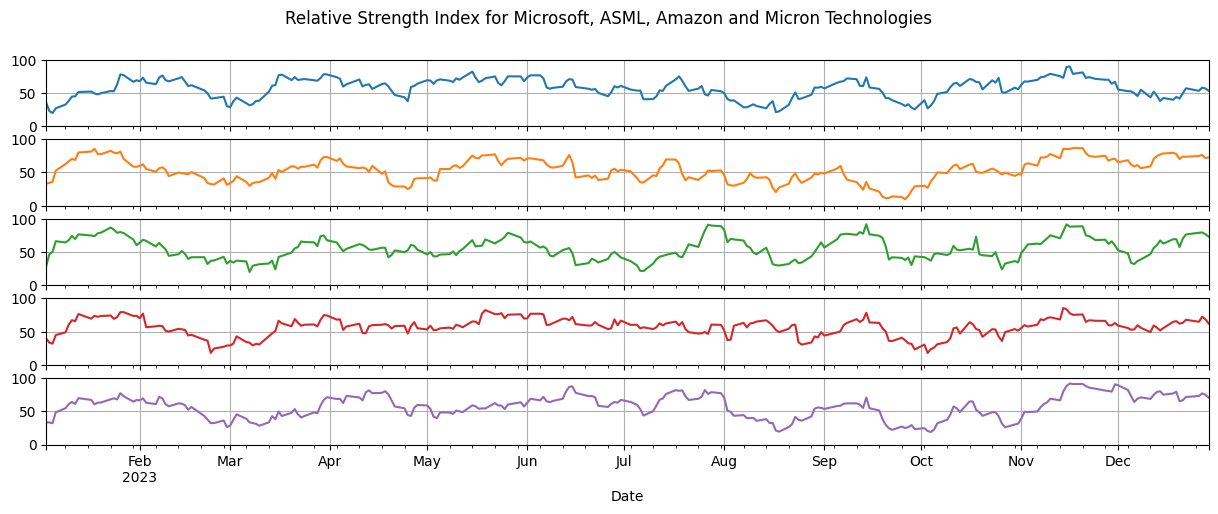

In [6]:
# Obtain the Relative Strength Index (RSI) for each company
rsi = companies.technicals.get_relative_strength_index()

# Show the RSI for each company
display(rsi)

# Plot the RSI for each company
rsi.plot(
    subplots=True,
    figsize=(15, 5),
    title="Relative Strength Index for Microsoft, ASML, Amazon and Micron Technologies",
    legend=False,
    grid=True,
    ylim=(0, 100),
    sharex=True,
)

Given that the models of the Technicals module are very flexible and merely contain the calculation, it is possible to directly use these models instead of the Toolkit as well given that you have your own data or are looking for specific alterations.

In [7]:
from financetoolkit.technicals import momentum_model, volatility_model

display(
    momentum_model.get_ichimoku_cloud(
        prices_low=pd.Series(range(70, 140, 1)),
        prices_high=pd.Series(range(90, 160, 1)),
        conversion_window=9,
        base_window=20,
        lead_span_b_window=40,
    )
)

display(
    volatility_model.get_bollinger_bands(
        prices=pd.Series([100, 105, 113, 126, 148]),
        window=2,
        num_std_dev=2,
    )
)

,Conversion Line,Base Line,Leading Span A,Leading Span B
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
65,141.0,135.5,129.25,116.5
66,142.0,136.5,130.25,117.5
67,143.0,137.5,131.25,118.5
68,144.0,138.5,132.25,119.5


,Upper Band,Middle Band,Lower Band,Close
0,NaN,NaN,NaN,100
1,109.57106781186548,102.5,95.42893218813452,105
2,120.31370849898477,109.0,97.68629150101523,113
3,137.88477631085024,119.5,101.11522368914976,126
4,168.1126983722081,137.0,105.88730162779191,148
